# Joint EDA: Pesticide, Croplands, Census & CDC PLACES

This notebook **joins all four datasets** in **county–year** form (one row per county per year) and runs exploratory data analysis on the combined data.

**Datasets joined:**
1. **USGS Pesticide Use** – county-level agricultural pesticide estimates (kg)
2. **USDA Cropland Data Layer** – county-level crop acreage
3. **US Census ACS** – county-level demographics (population, age, income, race)
4. **CDC PLACES** – county-level health outcomes (asthma, COPD prevalence)

**Join key:** 5-digit FIPS (state + county code)

**Target years:** 2016–2019. Data are in **county–year** form: one row per county per year (pesticide varies by year; census, cropland, and PLACES are county-level and repeated across years).

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `requests`. Optional: `rpy2` + R + CDCPLACES for PLACES if CDC CSV fails.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load Pesticide Data (County–Year)

Load USGS pesticide estimates for 2016–2019. We keep **one row per county per year** (no aggregation across years) so the joint dataset supports temporal splits and time trends. We offer **multiple aggregation options** and **pesticide categories** by chemical class from Shekhar et al. (2024): [A systematic review of pesticide exposure, associated risks, and long-term human health impacts](https://pmc.ncbi.nlm.nih.gov/articles/PMC11664077/).

**Chemical classes** (linked to respiratory/neurological effects in the literature):
- **Organophosphates** (OP): cholinesterase inhibitors; respiratory, neurotoxic
- **Organochlorines** (OC): persistent; neurotoxic, endocrine disruption
- **Carbamates**: reversible AChE inhibitors; respiratory effects
- **Pyrethroids**: neurotoxic; respiratory distress
- **Triazines** (e.g. atrazine): herbicides; cancer associations
- **Chlorophenoxy** (e.g. 2,4-D): herbicides
- **Other/Unclassified**

In [ ]:
# Pesticide URLs for 2016-2019
PEST_2016_17 = "https://www.sciencebase.gov/catalog/file/get/5e95c12282ce172707f2524e?f=__disk__62%2F83%2Fd3%2F6283d3501f1028b1ccc3976ea2e6de848bc2fef8&allowOpen=true"
PEST_2018 = "https://www.sciencebase.gov/catalog/file/get/6081a706d34e8564d686618e?f=__disk__58%2F6a%2Fed%2F586aed9a844eac0174a0600c8a7293ec4cda0265&allowOpen=true"
PEST_2019 = "https://www.sciencebase.gov/catalog/file/get/6081a924d34e8564d68661a1?f=__disk__08%2F42%2Fcd%2F0842cdac3a7d8b5056645a4dc08d1da96ad4e0b7&allowOpen=true"

df_pest = pd.read_csv(PEST_2016_17, sep="\t")
df_pest = df_pest[df_pest["YEAR"].isin([2016, 2017])]
df_pest = pd.concat([df_pest, pd.read_csv(PEST_2018, sep="\t"), pd.read_csv(PEST_2019, sep="\t")], ignore_index=True)

# Standardize FIPS
df_pest["STATE_FIPS"] = df_pest["STATE_FIPS_CODE"].astype(int).astype(str).str.zfill(2)
df_pest["COUNTY_FIPS"] = df_pest["COUNTY_FIPS_CODE"].astype(int).astype(str).str.zfill(3)
df_pest["FIPS"] = df_pest["STATE_FIPS"] + df_pest["COUNTY_FIPS"]
df_pest["EPEST_MEAN_KG"] = df_pest[["EPEST_LOW_KG", "EPEST_HIGH_KG"]].mean(axis=1)

# --- Pesticide classification by chemical class (Shekhar et al., 2024, PMC11664077) ---
# Compounds matched by substring (case-insensitive). Order matters: more specific first.
CHEMICAL_CLASS_KEYWORDS = {
    "Organochlorine": ["ddt", "aldrin", "endosulfan", "endrin", "chlordane", "lindane", "dieldrin", "heptachlor", "toxaphene", "mirex", "methoxychlor"],
    "Organophosphate": ["chlorpyrifos", "malathion", "parathion", "diazinon", "dichlorvos", "fenthion", "phorate", "ethion", "acephate", "dimethoate", "methamidophos", "terbufos", "phosmet"],
    "Carbamate": ["carbaryl", "carbofuran", "propoxur", "bendiocarb", "aldicarb", "methomyl", "thiodicarb", "oxamyl", "pirimicarb"],
    "Pyrethroid": ["permethrin", "cypermethrin", "deltamethrin", "lambda-cyhalothrin", "cyhalothrin", "bifenthrin", "esfenvalerate", "fenvalerate", "tefluthrin", "pyrethroid"],
    "Triazine": ["atrazine", "propazine", "terbutryn", "cyanazine", "simazine", "terbuthylazine"],
    "Chlorophenoxy": ["2,4-d", "2,4-dichlorophenoxy", "mcpa", "mcpb", "dicamba", "2,4-db"],
    "Anilide": ["alachlor", "pretilachlor", "metolachlor", "acetochlor", "propanil"],
}

def assign_chemical_class(compound: str) -> str:
    """Assign chemical class from compound name (case-insensitive substring match)."""
    c = str(compound).lower()
    for cls, keywords in CHEMICAL_CLASS_KEYWORDS.items():
        if any(kw in c for kw in keywords):
            return cls
    return "Other"

df_pest["chemical_class"] = df_pest["COMPOUND"].apply(assign_chemical_class)

# --- Compute aggregations at county-year level (keep YEAR for temporal analysis) ---
# 1. Total: sum all compounds per county per year
pest_total = df_pest.groupby(["FIPS", "YEAR"])["EPEST_MEAN_KG"].sum().reset_index()
pest_total = pest_total.rename(columns={"EPEST_MEAN_KG": "pesticide_total_kg"})

# 2. By class: one column per chemical class (kg) per county-year
pest_by_class = df_pest.groupby(["FIPS", "YEAR", "chemical_class"])["EPEST_MEAN_KG"].sum().reset_index()
pest_class_wide = pest_by_class.pivot(index=["FIPS", "YEAR"], columns="chemical_class", values="EPEST_MEAN_KG").fillna(0).reset_index()
class_cols = [c for c in pest_class_wide.columns if c not in ("FIPS", "YEAR")]
pest_class_wide.columns = ["FIPS", "YEAR"] + [f"pesticide_{c.lower()}_kg" for c in class_cols]

# 3. Respiratory-relevant: sum only OP, Carbamate, Pyrethroid (strongest respiratory links) per county-year
resp_classes = ["Organophosphate", "Carbamate", "Pyrethroid"]
df_resp = df_pest[df_pest["chemical_class"].isin(resp_classes)]
pest_resp = df_resp.groupby(["FIPS", "YEAR"])["EPEST_MEAN_KG"].sum().reset_index()
pest_resp = pest_resp.rename(columns={"EPEST_MEAN_KG": "pesticide_respiratory_kg"})

# 4. By compound: one column per compound (kg) per county-year
import re
def sanitize_compound_col(name):
    """Convert compound name to valid column name: pesticide_<sanitized>_kg"""
    s = re.sub(r"[^a-zA-Z0-9]", "_", str(name).strip()).lower()
    s = re.sub(r"_+", "_", s).strip("_")  # collapse multiple underscores
    return f"pesticide_{s}_kg" if s else "pesticide_unknown_kg"

pest_by_compound = df_pest.groupby(["FIPS", "YEAR", "COMPOUND"])["EPEST_MEAN_KG"].sum().reset_index()
pest_compound_wide = pest_by_compound.pivot(index=["FIPS", "YEAR"], columns="COMPOUND", values="EPEST_MEAN_KG").fillna(0).reset_index()
# Sanitize compound names for column headers; handle duplicates
seen = {}
new_cols = []
for c in pest_compound_wide.columns:
    if c in ("FIPS", "YEAR"):
        new_cols.append(c)
        continue
    name = sanitize_compound_col(c)
    seen[name] = seen.get(name, 0) + 1
    if seen[name] > 1:
        name = name.replace("_kg", f"_{seen[name]}_kg")
    new_cols.append(name)
pest_compound_wide.columns = new_cols

# Merge all into pest_county (one row per county-year)
pest_county = pest_total.merge(pest_class_wide, on=["FIPS", "YEAR"], how="left").merge(pest_resp, on=["FIPS", "YEAR"], how="left")
pest_county = pest_county.merge(pest_compound_wide, on=["FIPS", "YEAR"], how="left")
pest_county["pesticide_respiratory_kg"] = pest_county["pesticide_respiratory_kg"].fillna(0)

print("Pesticide (county-year):", pest_county.shape)
print("  - Total + respiratory +", pest_class_wide.shape[1] - 2, "class cols +", pest_compound_wide.shape[1] - 2, "compound cols (one row per county-year)")
print("Chemical class distribution:", df_pest["chemical_class"].value_counts())
pest_county.head()


Pesticide (county-level): (3066, 446)
  - Total + respiratory + 8 class cols + 435 compound cols
Chemical class distribution: chemical_class
Other              983889
Pyrethroid          62367
Anilide             47775
Organophosphate     42213
Chlorophenoxy       36944
Triazine            21907
Carbamate           17467
Organochlorine          7
Name: count, dtype: int64


,FIPS,pesticide_total_kg,pesticide_anilide_kg,pesticide_carbamate_kg,pesticide_chlorophenoxy_kg,pesticide_organochlorine_kg,pesticide_organophosphate_kg,pesticide_other_kg,pesticide_pyrethroid_kg,pesticide_triazine_kg,...,pesticide_trifluralin_kg,pesticide_triflusulfuron_kg,pesticide_trinexapac_kg,pesticide_triticonazole_kg,pesticide_uniconazole_kg,pesticide_vinclozolin_kg,pesticide_zeta_cypermethrin_kg,pesticide_zinc_kg,pesticide_ziram_kg,pesticide_zoxamide_kg
0,01001,30495.4625,3202.6000,224.125000,3851.0625,0.0,850.6125,21456.2500,160.8875,749.9250,...,321.300000,0.0,0.0,0.0,0.0,0.0,8.016667,0.0,0.0,0.0
1,01003,273490.5000,57142.8000,520.912500,8724.3625,0.0,6713.1125,180979.6750,1453.4625,17956.1750,...,964.933333,0.0,0.0,0.0,0.0,0.0,32.066667,0.0,0.0,0.0
2,01005,46204.8000,3368.0125,204.400000,8969.6750,0.0,1390.7625,30722.5500,316.1750,1233.2250,...,288.300000,0.0,0.0,0.0,0.0,0.0,7.183333,0.0,0.0,0.0
3,01007,9323.9250,1552.7125,8.866667,2425.0625,0.0,157.9875,4423.7375,35.2625,722.5125,...,98.133333,0.0,0.0,0.0,0.0,0.0,4.716667,0.0,0.0,0.0
4,01009,32072.3125,3111.4125,73.487500,12462.4375,0.0,421.4125,15529.5125,71.1750,402.8750,...,167.433333,0.0,0.0,0.0,0.0,0.0,19.250000,0.0,73.7,0.0


## 2. Load Census Demographics (County-level)

Includes **race percentages** (pct_white, pct_black, pct_asian, pct_hispanic) as demographic confounders for respiratory health.

In [48]:
CENSUS_BASE = "https://api.census.gov/data"
VARS = ["NAME", "B01003_001E", "B01002_001E", "B19013_001E", "B03002_001E", "B03002_003E", "B03002_004E", "B03002_006E", "B03002_012E"]

r = requests.get(f"{CENSUS_BASE}/2019/acs/acs5", params={"get": ",".join(VARS), "for": "county:*", "in": "state:*"})
r.raise_for_status()
data = r.json()
census = pd.DataFrame(data[1:], columns=data[0])

census["FIPS"] = census["state"].astype(str).str.zfill(2) + census["county"].astype(str).str.zfill(3)
for c in ["B01003_001E", "B01002_001E", "B19013_001E", "B03002_001E", "B03002_003E", "B03002_004E", "B03002_006E", "B03002_012E"]:
    census[c] = pd.to_numeric(census[c], errors="coerce")

census = census.rename(columns={"B01003_001E": "population", "B01002_001E": "median_age", "B19013_001E": "median_income", "B03002_001E": "pop_race"})
# Race percentages (demographic confounders for respiratory health)
for race, col in [("pct_white", "B03002_003E"), ("pct_black", "B03002_004E"), ("pct_asian", "B03002_006E"), ("pct_hispanic", "B03002_012E")]:
    census[race] = 100 * census[col] / census["pop_race"].replace(0, np.nan)
print("Census (county-level):", census.shape)
census.head()

Census (county-level): (3220, 16)


,NAME,population,median_age,median_income,pop_race,B03002_003E,B03002_004E,B03002_006E,B03002_012E,state,county,FIPS,pct_white,pct_black,pct_asian,pct_hispanic
0,"Fayette County, Illinois",21565,41.9,46650,21565,19868,1007,116,403,17,051,17051,92.130767,4.669604,0.537909,1.868769
1,"Logan County, Illinois",29003,40.1,57308,29003,25049,1984,218,985,17,107,17107,86.366928,6.840672,0.751646,3.396200
2,"Saline County, Illinois",23994,42.2,44090,23994,21957,632,173,428,17,165,17165,91.510378,2.633992,0.721014,1.783779
3,"Lake County, Illinois",701473,38.4,89427,701473,432361,45923,53654,152141,17,097,17097,61.636157,6.546653,7.648762,21.688789
4,"Massac County, Illinois",14219,43.5,47481,14219,12547,830,29,419,17,127,17127,88.241086,5.837260,0.203952,2.946761


## 3. Load Cropland Data (County-level)

The CropScape API returns **acreage by land-cover category** (e.g., Corn, Soybeans, Cotton, Forest, Developed). We extract multiple factors beyond total acres.

**Fetch strategy:** We fetch CDL for **all** pesticide counties using **parallel requests**. A short **probe** (15 test requests) runs first to find a safe concurrency level — the API doesn't publish rate limits, so we try 10 workers, then 5, 2, or 1 if we hit 429/503 errors.

**Cropland factors extracted** (likely relevant for pesticide/health modeling):

| Factor | Rationale |
|--------|------------|
| `cropland_acres` | Total cultivated cropland — baseline agricultural intensity |
| `pct_cropland` | Share of county in crops — intensity relative to land area |
| `corn_acres`, `soybean_acres`, `cotton_acres` | Major row crops — different pesticide profiles (e.g., atrazine on corn) |
| `fruit_veg_acres` | Orchards, vineyards, vegetables — often higher pesticide use per acre |
| `hay_acres` | Alfalfa/hay — moderate use |
| `cropland_diversity` | Number of crop types — monoculture vs. mixed farming |

In [49]:
import xml.etree.ElementTree as ET

CDL_API = "https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLStat"

def get_county_cdl(year: int, fips: str) -> pd.DataFrame:
    params = {"year": year, "fips": fips, "format": "csv"}
    r = requests.get(CDL_API, params=params)
    r.raise_for_status()
    root = ET.fromstring(r.text)
    ns = {"ns": "http://cropscape.csiss.gmu.edu/CDLService/"}
    url_elem = root.find(".//ns:returnURL", ns) or root.find(".//returnURL")
    data_url = url_elem.text.strip() if url_elem is not None else f"https://nassgeodata.gmu.edu/webservice/nass_data_cache/byfips/CDL_{year}_{fips}.csv"
    r2 = requests.get(data_url)
    r2.raise_for_status()
    return pd.read_csv(StringIO(r2.text))

# Fetch cropland for ALL pesticide counties (parallel requests for speed)
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

all_fips = pest_county["FIPS"].astype(str).str.zfill(5).unique().tolist()

# Probe: discover safe concurrency (API doesn't publish rate limits)
# Try a small batch; if we get 429/503, reduce workers and retry
def probe_safe_workers(max_workers_start=10, probe_size=15):
    probe_fips = all_fips[:probe_size]
    for n in [max_workers_start, 5, 2, 1]:
        errors = 0
        with ThreadPoolExecutor(max_workers=n) as ex:
            futures = [ex.submit(get_county_cdl, 2019, f) for f in probe_fips]
            for f in as_completed(futures):
                try:
                    f.result()
                except requests.exceptions.HTTPError as e:
                    if e.response.status_code in (429, 503):
                        errors += 1
                except Exception:
                    errors += 1
        if errors == 0:
            print(f"Probe OK with {n} worker(s). Using N_WORKERS={n}.")
            return n
        print(f"Probe with {n} worker(s): {errors} rate-limit/server errors. Trying fewer...")
        time.sleep(2)  # brief pause before retry
    return 1

N_WORKERS = probe_safe_workers(max_workers_start=10, probe_size=15)

# CDL category groupings (match by substring in category name; CDL uses "Corn", "Soybeans", etc.)
CROP_GROUPS = {
    "corn_acres": ["corn"],
    "soybean_acres": ["soybean"],
    "cotton_acres": ["cotton"],
    "wheat_acres": ["wheat"],
    "hay_acres": ["hay", "alfalfa"],
    "fruit_veg_acres": ["orchard", "vineyard", "fruit", "vegetable", "grapes", "apple", "citrus", "berry", "tomato", "peach", "almond"],
    "rice_acres": ["rice"],
    "sorghum_acres": ["sorghum"],
}
# Non-crop (exclude from cropland total): developed, water, forest, wetland, barren, etc.
NON_CROP = ["developed", "open water", "water", "forest", "wetland", "barren", "shrubland", "grassland", "pasture"]

def extract_crop_features(df_c: pd.DataFrame) -> dict:
    """Extract cropland features from CDL stat response."""
    acre_col = next((c for c in ["Acres", "ACRES", "acres"] if c in df_c.columns), None)
    if acre_col is None:
        cand = [c for c in df_c.columns if "acre" in c.lower() or "area" in c.lower()]
        acre_col = cand[0] if cand else df_c.select_dtypes(include=[np.number]).columns[0]
    name_col = next((c for c in ["Category", "Crop", "Class_Name", "NAME"] if c in df_c.columns), df_c.columns[0])
    df_c = df_c.copy()
    df_c["_name"] = df_c[name_col].astype(str).str.lower()
    total_area = df_c[acre_col].sum()
    # Cropland = cultivated crops (exclude non-crop)
    crop_mask = ~df_c["_name"].str.contains("|".join(NON_CROP), case=False, na=False)
    cropland_total = df_c.loc[crop_mask, acre_col].sum()
    out = {"cropland_acres": cropland_total, "total_area_acres": total_area, "pct_cropland": 100 * cropland_total / total_area if total_area > 0 else 0}
    for feat, keywords in CROP_GROUPS.items():
        mask = df_c["_name"].str.contains("|".join(keywords), case=False, na=False)
        out[feat] = df_c.loc[mask, acre_col].sum()
    out["cropland_diversity"] = crop_mask.sum()  # number of distinct crop categories
    return out

def fetch_one(fips):
    try:
        df_c = get_county_cdl(2019, fips)
        feats = extract_crop_features(df_c)
        feats["FIPS"] = fips
        return feats
    except Exception:
        return None

cropland_rows = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(fetch_one, f): f for f in all_fips}
    for i, future in enumerate(as_completed(futures)):
        if (i + 1) % 500 == 0:
            print(f"  Fetched {i + 1}/{len(all_fips)} counties...")
        result = future.result()
        if result is not None:
            cropland_rows.append(result)

cropland = pd.DataFrame(cropland_rows)
print("Cropland (county-level):", cropland.shape)
print("Columns:", list(cropland.columns))
cropland.head()

Probe OK with 10 worker(s). Using N_WORKERS=10.
  Fetched 500/3066 counties...
  Fetched 1000/3066 counties...
  Fetched 1500/3066 counties...
  Fetched 2000/3066 counties...
  Fetched 2500/3066 counties...
  Fetched 3000/3066 counties...
Cropland (county-level): (3054, 13)
Columns: ['cropland_acres', 'total_area_acres', 'pct_cropland', 'corn_acres', 'soybean_acres', 'cotton_acres', 'wheat_acres', 'hay_acres', 'fruit_veg_acres', 'rice_acres', 'sorghum_acres', 'cropland_diversity', 'FIPS']


,cropland_acres,total_area_acres,pct_cropland,corn_acres,soybean_acres,cotton_acres,wheat_acres,hay_acres,fruit_veg_acres,rice_acres,sorghum_acres,cropland_diversity,FIPS
0,416388.6,416388.6,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38,01009
1,578885.9,578885.9,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41,01005
2,386553.2,386553.2,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38,01001
3,400710.4,400710.4,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40,01011
4,385952.2,385952.2,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36,01017


## 4. Load CDC PLACES (County-level)

Uses the **CDCPLACES R package** via `rpy2`, same as `EDA/cdc-places/places_eda.ipynb`. Requires R with CDCPLACES installed.

**Measures pulled:**
- **CASTHMA**, **COPD** — respiratory outcomes (targets)
- **CSMOKING** — current cigarette smoking % (tobacco confounder)
- **OBESITY**, **DIABETES** — respiratory/demographic confounders

In [ ]:
# Pull COUNTY-level PLACES data via R CDCPLACES (same as places_eda.ipynb)
import os
import tempfile
from rpy2.robjects import r
from rpy2.robjects.vectors import StrVector
from rpy2.robjects.packages import importr

try:
    cdcplaces = importr("CDCPLACES")
    # Respiratory outcomes + tobacco (confounder) + obesity/diabetes (respiratory confounders)
    PLACES_MEASURES = ["CASTHMA", "COPD", "CSMOKING", "OBESITY", "DIABETES"]
    r.assign("measures_r", StrVector(PLACES_MEASURES))
    r.assign("release_r", "2023")
    r('places_county <- get_places(geography = "county", state = NULL, measure = measures_r, release = release_r, geometry = FALSE)')

    tmp_csv = os.path.join(tempfile.gettempdir(), "places_county_r.csv")
    r.assign("tmp_path", tmp_csv)
    r('''
    atomic <- sapply(places_county, is.atomic)
    places_county <- places_county[, atomic, drop = FALSE]
    write.csv(places_county, tmp_path, row.names = FALSE)
    ''')

    county_df = pd.read_csv(tmp_csv)
    try:
        os.remove(tmp_csv)
    except OSError:
        pass

    county_df.columns = [c.strip().lower().replace(" ", "_") for c in county_df.columns]
    measure_col = "measureid" if "measureid" in county_df.columns else [c for c in county_df.columns if "measure" in c][0]
    value_col = "data_value" if "data_value" in county_df.columns else [c for c in county_df.columns if "value" in c and "conf" not in c][0]

    county_wide = county_df.pivot_table(index="locationid", columns=measure_col, values=value_col, aggfunc="first").reset_index()
    county_wide["FIPS"] = county_wide["locationid"].astype(str).str.zfill(5)
    keep_cols = ["FIPS"] + [c for c in PLACES_MEASURES if c in county_wide.columns]
    places = county_wide[keep_cols].copy()
    print("Loaded PLACES via R (CDCPLACES)")
except Exception as e:
    print(f"CDCPLACES failed: {e}")
    places = pd.DataFrame(columns=["FIPS", "CASTHMA", "COPD", "CSMOKING", "OBESITY", "DIABETES"])

print("PLACES (county-level):", places.shape)
places.head()

Loaded PLACES via R (CDCPLACES)
PLACES (county-level): (3077, 6)


measureid,FIPS,CASTHMA,COPD,CSMOKING,OBESITY,DIABETES
0,00059,9.7,5.7,13.8,33.0,11.3
1,01001,10.1,6.8,16.8,39.3,10.7
2,01003,9.7,8.1,14.5,37.4,9.8
3,01005,11.3,9.7,25.0,43.3,15.6
4,01007,10.3,8.6,22.0,39.6,14.1


## 5. Join All Datasets (County–Year on FIPS)

In [51]:
# Start with pesticide (county-year: one row per FIPS per year)
joint = pest_county.copy()

# Merge census, cropland, PLACES on FIPS (county-level; repeated for each year)
census_cols = ["FIPS", "NAME", "population", "median_age", "median_income"]
census_cols += [c for c in ["pct_white", "pct_black", "pct_asian", "pct_hispanic"] if c in census.columns]
census_sub = census[census_cols].copy()
joint = joint.merge(census_sub, on="FIPS", how="left", suffixes=("", "_census"))

# Merge cropland (left join)
joint = joint.merge(cropland, on="FIPS", how="left")

joint = joint.merge(places, on="FIPS", how="left")
joint["state_fips"] = joint["FIPS"].astype(str).str.zfill(5).str[:2]

print("Joint dataset shape (county-year rows):", joint.shape)
print("  Years:", sorted(joint["YEAR"].dropna().unique().tolist()))
print("\nColumn coverage:")
print(joint.notna().sum())
joint.head(10)

Joint dataset shape: (3066, 471)

Column coverage:
FIPS                          3066
pesticide_total_kg            3066
pesticide_anilide_kg          3066
pesticide_carbamate_kg        3066
pesticide_chlorophenoxy_kg    3066
                              ... 
CASTHMA                       2999
COPD                          2999
CSMOKING                      2999
OBESITY                       2999
DIABETES                      2999
Length: 471, dtype: int64


,FIPS,pesticide_total_kg,pesticide_anilide_kg,pesticide_carbamate_kg,pesticide_chlorophenoxy_kg,pesticide_organochlorine_kg,pesticide_organophosphate_kg,pesticide_other_kg,pesticide_pyrethroid_kg,pesticide_triazine_kg,...,hay_acres,fruit_veg_acres,rice_acres,sorghum_acres,cropland_diversity,CASTHMA,COPD,CSMOKING,OBESITY,DIABETES
0,01001,30495.4625,3202.6000,224.125000,3851.0625,0.0,850.6125,21456.2500,160.8875,749.9250,...,0.0,0.0,0.0,0.0,38.0,10.1,6.8,16.8,39.3,10.7
1,01003,273490.5000,57142.8000,520.912500,8724.3625,0.0,6713.1125,180979.6750,1453.4625,17956.1750,...,NaN,NaN,NaN,NaN,NaN,9.7,8.1,14.5,37.4,9.8
2,01005,46204.8000,3368.0125,204.400000,8969.6750,0.0,1390.7625,30722.5500,316.1750,1233.2250,...,0.0,0.0,0.0,0.0,41.0,11.3,9.7,25.0,43.3,15.6
3,01007,9323.9250,1552.7125,8.866667,2425.0625,0.0,157.9875,4423.7375,35.2625,722.5125,...,0.0,0.0,0.0,0.0,34.0,10.3,8.6,22.0,39.6,14.1
4,01009,32072.3125,3111.4125,73.487500,12462.4375,0.0,421.4125,15529.5125,71.1750,402.8750,...,0.0,0.0,0.0,0.0,38.0,10.0,7.8,19.6,37.9,12.8
5,01011,9316.7125,1074.0000,57.000000,3128.1750,0.0,207.5875,3925.6250,23.0750,901.2500,...,0.0,0.0,0.0,0.0,40.0,11.6,9.8,25.5,49.2,18.7
6,01013,33311.0625,5100.8875,89.012500,1880.2750,0.0,694.4375,18092.8000,216.8250,7236.8250,...,0.0,0.0,0.0,0.0,34.0,11.0,8.2,20.1,41.6,14.0
7,01015,29699.9000,4519.5000,43.487500,6299.6625,0.0,638.3625,17104.6875,97.8125,996.3875,...,NaN,NaN,NaN,NaN,NaN,10.7,8.2,20.8,38.9,14.1
8,01017,13595.5500,1423.8875,9.925000,5808.9375,0.0,379.7500,5823.3750,25.4125,124.2625,...,0.0,0.0,0.0,0.0,36.0,10.9,9.6,19.5,44.0,16.5
9,01019,103636.3250,15895.6750,187.250000,8809.2625,0.0,2735.7125,72730.3875,429.3250,2848.7125,...,0.0,0.0,0.0,0.0,40.0,10.6,11.3,22.2,38.0,15.1


## 6. Joint EDA

In [52]:
joint.describe()

joint.head

<bound method NDFrame.head of        FIPS  pesticide_total_kg  pesticide_anilide_kg  pesticide_carbamate_kg  \
0     01001          30495.4625             3202.6000              224.125000   
1     01003         273490.5000            57142.8000              520.912500   
2     01005          46204.8000             3368.0125              204.400000   
3     01007           9323.9250             1552.7125                8.866667   
4     01009          32072.3125             3111.4125               73.487500   
...     ...                 ...                   ...                     ...   
3061  56037           7195.6500                0.0000                0.000000   
3062  56039           1940.3250                0.0000                0.200000   
3063  56041           4224.0750               50.8500                0.000000   
3064  56043          31161.0875             1292.0625               53.600000   
3065  56045           5419.9500                9.2000              182.500000  

### 6a. Missingness: Geographic distribution and correlated patterns

We check (1) whether missingness is geographically clustered (e.g., certain states) and (2) whether missingness in one dataset tends to co-occur with missingness in others.

**Note:** Cropland is now fetched for all counties (parallel API requests). Any remaining missingness is from API failures for specific counties.

In [53]:
# Missingness indicators (1 = has data, 0 = missing)
print("Overall missingness:")
print("  Pesticide (total_kg):", joint["pesticide_total_kg"].isna().sum(), "counties missing (base dataset)")
print("  Census (population):", joint["population"].isna().sum(), "counties missing")
print("  Cropland:", joint["cropland_acres"].isna().sum(), "counties missing")
print("  PLACES (CASTHMA):", joint["CASTHMA"].isna().sum(), "counties missing")
print()
joint["state_fips"] = joint["FIPS"].astype(str).str.zfill(5).str[:2]
miss = pd.DataFrame({
    "has_pesticide": joint["pesticide_total_kg"].notna().astype(int),
    "has_census": joint["population"].notna().astype(int),
    "has_cropland": joint["cropland_acres"].notna().astype(int),
    "has_places": joint["CASTHMA"].notna().astype(int),
}, index=joint.index)
miss["state_fips"] = joint["state_fips"]
miss["n_missing"] = 4 - miss[["has_pesticide", "has_census", "has_cropland", "has_places"]].sum(axis=1)

# Geographic distribution: % missing by state
state_miss = miss.groupby("state_fips").agg(
    n_counties=("has_census", "count"),
    pct_missing_pesticide=("has_pesticide", lambda x: 100 * (1 - x.mean())),
    pct_missing_census=("has_census", lambda x: 100 * (1 - x.mean())),
    pct_missing_cropland=("has_cropland", lambda x: 100 * (1 - x.mean())),
    pct_missing_places=("has_places", lambda x: 100 * (1 - x.mean())),
).round(1)
state_miss = state_miss[state_miss["n_counties"] >= 5]  # at least 5 counties
state_miss.sort_values("pct_missing_cropland", ascending=False).head(15)

Overall missingness:
  Pesticide (total_kg): 0 counties missing (base dataset)
  Census (population): 0 counties missing
  Cropland: 12 counties missing
  PLACES (CASTHMA): 67 counties missing



,n_counties,pct_missing_pesticide,pct_missing_census,pct_missing_cropland,pct_missing_places
state_fips,,,,,
01,67,0.0,0.0,3.0,0.0
35,33,0.0,0.0,3.0,0.0
53,39,0.0,0.0,2.6,0.0
39,88,0.0,0.0,2.3,0.0
21,120,0.0,0.0,1.7,0.0
05,75,0.0,0.0,1.3,0.0
18,92,0.0,0.0,1.1,0.0
17,102,0.0,0.0,1.0,0.0
48,254,0.0,0.0,0.4,0.0


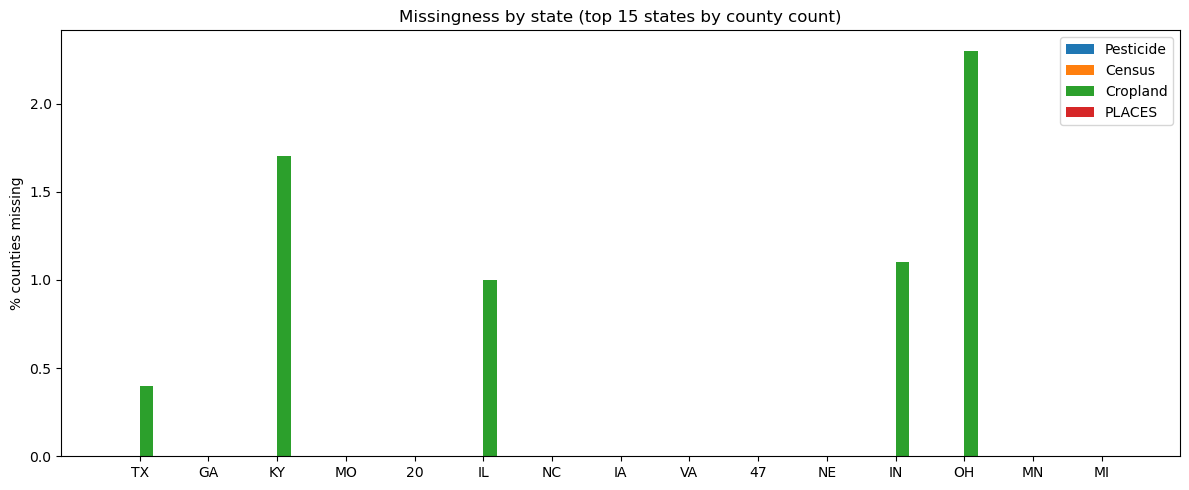

In [54]:
# Bar chart: missingness by state (states with most counties)
# State FIPS codes: 01=AL, 06=CA, 12=FL, 13=GA, 17=IL, 18=IN, 19=IA, 21=KY, 22=LA, 26=MI, 27=MN, 28=MS, 29=MO, 31=NE, 36=NY, 37=NC, 39=OH, 40=OK, 41=OR, 42=PA, 48=TX, 51=VA
STATE_ABBR = {"01":"AL","06":"CA","12":"FL","13":"GA","17":"IL","18":"IN","19":"IA","21":"KY","22":"LA","26":"MI","27":"MN","28":"MS","29":"MO","31":"NE","36":"NY","37":"NC","39":"OH","40":"OK","41":"OR","42":"PA","48":"TX","51":"VA"}
fig, ax = plt.subplots(figsize=(12, 5))
plot_states = state_miss.nlargest(15, "n_counties").index
labels = [STATE_ABBR.get(s, s) for s in plot_states]
x = np.arange(len(plot_states))
w = 0.2
ax.bar(x - 1.5*w, state_miss.loc[plot_states, "pct_missing_pesticide"], width=w, label="Pesticide", color="C0")
ax.bar(x - 0.5*w, state_miss.loc[plot_states, "pct_missing_census"], width=w, label="Census", color="C1")
ax.bar(x + 0.5*w, state_miss.loc[plot_states, "pct_missing_cropland"], width=w, label="Cropland", color="C2")
ax.bar(x + 1.5*w, state_miss.loc[plot_states, "pct_missing_places"], width=w, label="PLACES", color="C3")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% counties missing")
ax.set_title("Missingness by state (top 15 states by county count)")
ax.legend()
plt.tight_layout()
plt.show()

In [55]:
# Correlated missingness: do the same counties tend to be missing across datasets?
miss_missing = 1 - miss[["has_pesticide", "has_census", "has_cropland", "has_places"]]
miss_missing.columns = ["missing_pesticide", "missing_census", "missing_cropland", "missing_places"]
print("Correlation of MISSING indicators (1=missing, 0=has data):")
print("  Positive = counties missing in one tend to be missing in the other (geographic/structural overlap)")
print(miss_missing.corr().round(3))
print("\nCrosstab: Census missing × Cropland missing")
print(pd.crosstab(miss["has_census"] == 0, miss["has_cropland"] == 0, margins=True))
print("\nCrosstab: Census missing × PLACES missing")
print(pd.crosstab(miss["has_census"] == 0, miss["has_places"] == 0, margins=True))
print("\nCrosstab: Cropland missing × PLACES missing")
print(pd.crosstab(miss["has_cropland"] == 0, miss["has_places"] == 0, margins=True))

Correlation of MISSING indicators (1=missing, 0=has data):
  Positive = counties missing in one tend to be missing in the other (geographic/structural overlap)
                   missing_pesticide  missing_census  missing_cropland  \
missing_pesticide                NaN             NaN               NaN   
missing_census                   NaN             NaN               NaN   
missing_cropland                 NaN             NaN             1.000   
missing_places                   NaN             NaN            -0.009   

                   missing_places  
missing_pesticide             NaN  
missing_census                NaN  
missing_cropland           -0.009  
missing_places              1.000  

Crosstab: Census missing × Cropland missing
has_cropland  False  True   All
has_census                     
False          3054    12  3066
All            3054    12  3066

Crosstab: Census missing × PLACES missing
has_places  False  True   All
has_census                   
False        

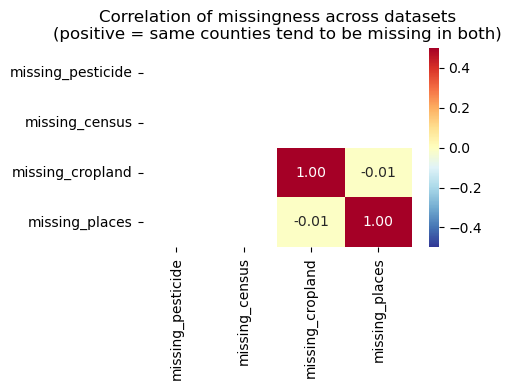

In [56]:
# Heatmap: correlation of missingness across datasets
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(miss_missing.corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title("Correlation of missingness across datasets\n(positive = same counties tend to be missing in both)")
plt.tight_layout()
plt.show()

### 6b. Correlation matrix

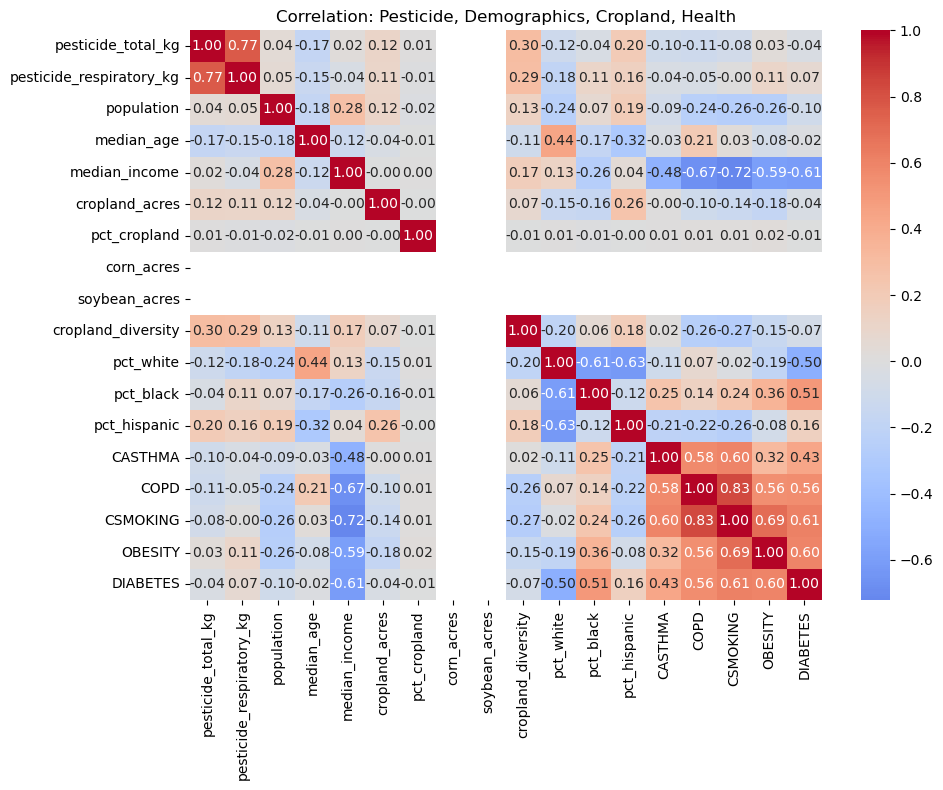

In [57]:
# Correlation matrix of key numeric variables
key_cols = [
    "pesticide_total_kg", "pesticide_respiratory_kg", "population", "median_age", "median_income",
    "cropland_acres", "pct_cropland", "corn_acres", "soybean_acres", "cropland_diversity",
    "pct_white", "pct_black", "pct_hispanic",
    "CASTHMA", "COPD", "CSMOKING", "OBESITY", "DIABETES"
]
key_cols = [c for c in key_cols if c in joint.columns]
corr_df = joint[key_cols].replace([-666666666, -222222222], np.nan)
corr_df = corr_df[(corr_df >= 0).all(axis=1) | corr_df.isna().any(axis=1)]
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Pesticide, Demographics, Cropland, Health")
plt.tight_layout()
plt.show()

### 6c. Distribution maps across continental US

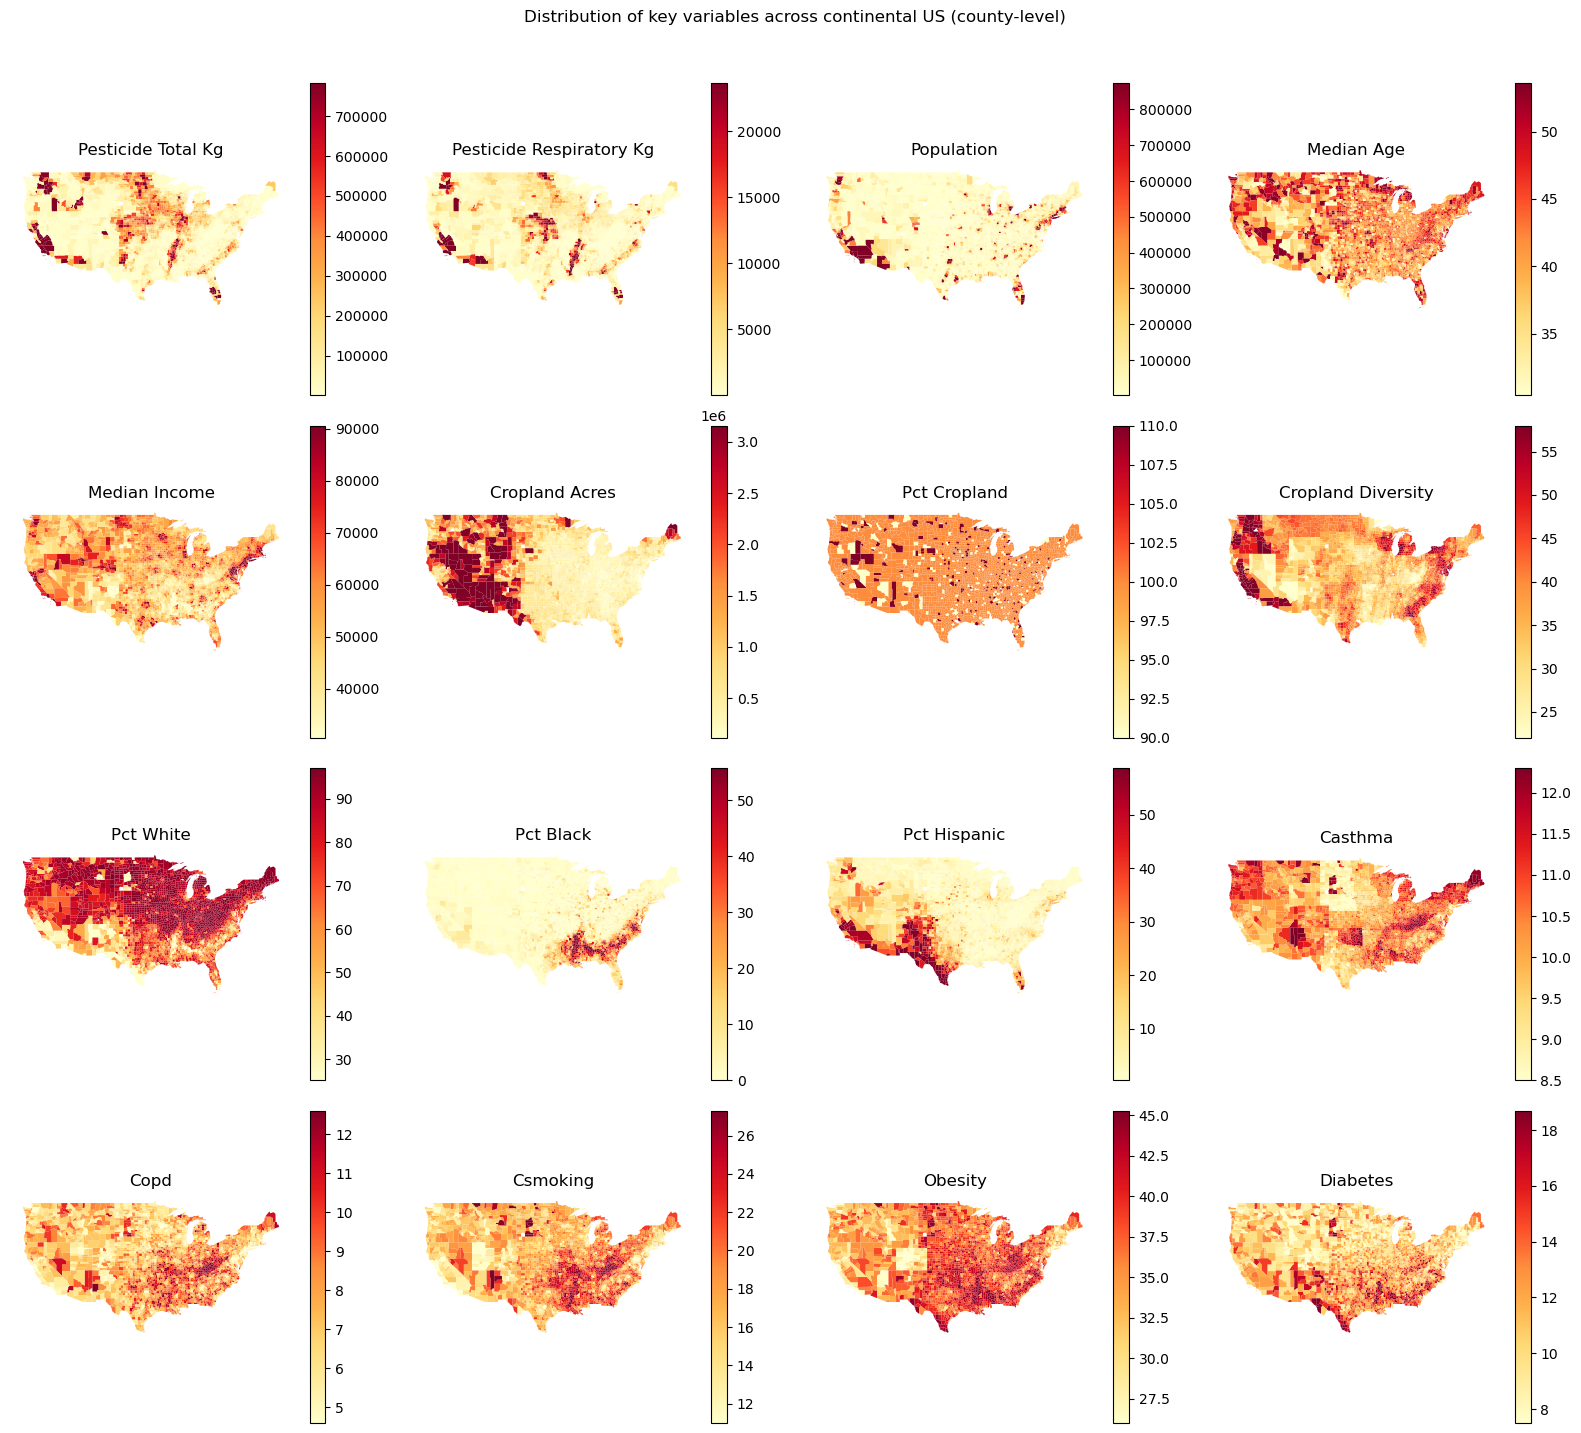

In [62]:
# Choropleth maps: distribution of each variable across continental US
try:
    import geopandas as gpd
    COUNTIES_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
    counties_gdf = gpd.read_file(COUNTIES_URL)
    
    def to_fips5(x):
        if pd.isna(x): return ""
        try: return str(int(float(x))).zfill(5)
        except (ValueError, TypeError): return str(x).replace(".0", "").zfill(5)[:5]
    
    id_series = counties_gdf["id"] if "id" in counties_gdf.columns else counties_gdf.index.astype(str)
    counties_gdf["FIPS"] = id_series.apply(to_fips5)
    counties_gdf = counties_gdf[counties_gdf["FIPS"].str.len() == 5]
    
    # Continental US: exclude AK (02), HI (15), PR (72), territories (60,66,69,78)
    exclude_states = ["02", "15", "72", "60", "66", "69", "78"]
    counties_cont = counties_gdf[~counties_gdf["FIPS"].str[:2].isin(exclude_states)]
    
    map_vars = [
        "pesticide_total_kg", "pesticide_respiratory_kg", "population", "median_age", "median_income",
        "cropland_acres", "pct_cropland", "cropland_diversity",
        "pct_white", "pct_black", "pct_hispanic",
        "CASTHMA", "COPD", "CSMOKING", "OBESITY", "DIABETES"
    ]
    map_vars = [c for c in map_vars if c in joint.columns]
    
    # One row per county for map (mean across years)
    map_df = joint.groupby("FIPS", as_index=True)[map_vars].mean().reset_index()
    map_df["FIPS"] = map_df["FIPS"].astype(str).str.zfill(5)
    merged = counties_cont.merge(map_df[["FIPS"] + map_vars], on="FIPS", how="inner")
    
    n_vars = len(map_vars)
    n_cols = 4
    n_rows = (n_vars + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for i, var in enumerate(map_vars):
        ax = axes[i]
        merged_plot = merged.dropna(subset=[var])
        vmin, vmax = merged_plot[var].quantile(0.02), merged_plot[var].quantile(0.98)
        merged_plot.plot(column=var, ax=ax, legend=True, cmap="YlOrRd", edgecolor="none", linewidth=0.1, vmin=vmin, vmax=vmax)
        ax.set_title(var.replace("_", " ").title())
        ax.axis("off")
    
    for j in range(len(map_vars), len(axes)):
        axes[j].axis("off")
    
    plt.suptitle("Distribution of key variables across continental US (county-level)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install geopandas for choropleth maps: pip install geopandas")

### 6d. Pesticide vs. respiratory outcomes

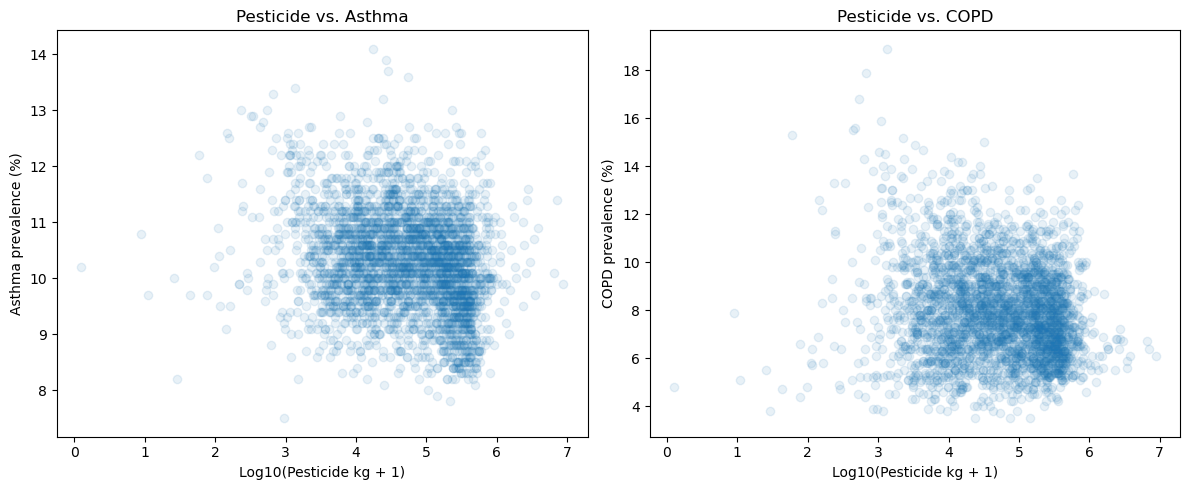

In [70]:
# Pesticide vs. respiratory outcomes (where PLACES available)
plot_df = joint.dropna(subset=["pesticide_respiratory_kg", "CASTHMA", "COPD"])
if len(plot_df) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(np.log10(plot_df["pesticide_total_kg"] + 1), plot_df["CASTHMA"], alpha=0.1)
    axes[0].set_xlabel("Log10(Pesticide kg + 1)")
    axes[0].set_ylabel("Asthma prevalence (%)")
    axes[0].set_title("Pesticide vs. Asthma")
    axes[1].scatter(np.log10(plot_df["pesticide_total_kg"] + 1), plot_df["COPD"], alpha=0.1)
    axes[1].set_xlabel("Log10(Pesticide kg + 1)")
    axes[1].set_ylabel("COPD prevalence (%)")
    axes[1].set_title("Pesticide vs. COPD")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient PLACES data for scatter. Run PLACES load (CDC URL or R) first.")

### 6e. Cropland vs. Pesticide

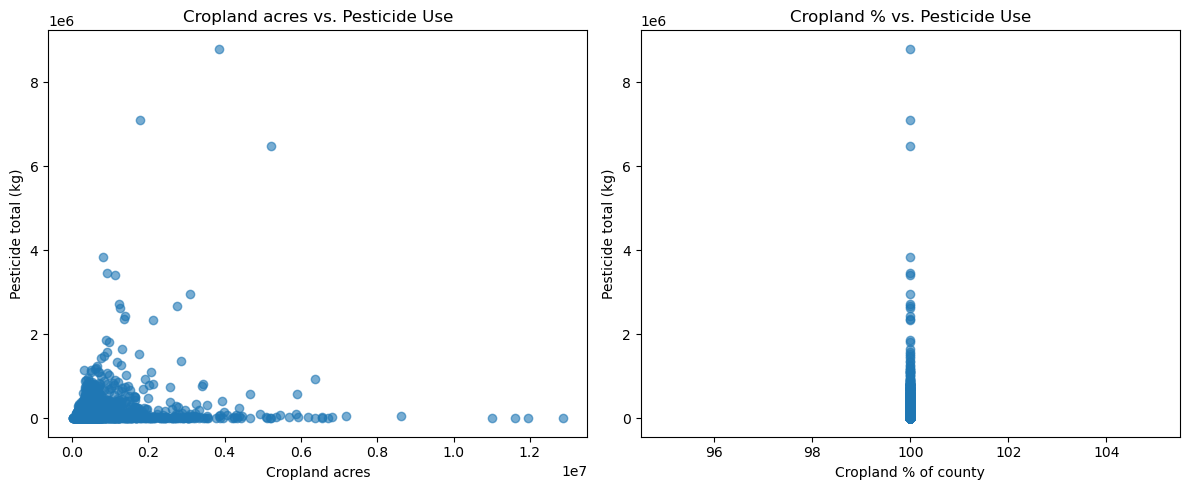

In [ ]:
# Cropland vs. Pesticide (where cropland available)
plot_df = joint.dropna(subset=["cropland_acres", "pesticide_total_kg"])
if len(plot_df) > 5:
    n_plots = 2 if "pct_cropland" in plot_df.columns else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.atleast_1d(axes)
    axes[0].scatter(plot_df["cropland_acres"], plot_df["pesticide_total_kg"], alpha=0.3)
    axes[0].set_xlabel("Cropland acres")
    axes[0].set_ylabel("Pesticide total (kg)")
    axes[0].set_title("Cropland acres vs. Pesticide Use")
    if n_plots > 1:
        axes[1].scatter(plot_df["pct_cropland"], plot_df["pesticide_total_kg"], alpha=0.6)
        axes[1].set_xlabel("Cropland % of county")
        axes[1].set_ylabel("Pesticide total (kg)")
        axes[1].set_title("Cropland % vs. Pesticide Use")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient cropland data.")

### 6f. Save joint dataset

In [61]:
# Optional: Save joint dataset for modeling
joint.to_csv("../data/joint_county_year_2016_2019.csv", index=False)